In [1]:
# import dependencies
%matplotlib inline
import os
import sys
import spatioev as se
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import Scimap
import scimap as sm

from spatioev.config import ClusteringConfig

Running SCIMAP  2.3.5


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/mpl_scatter_density/__init__.py:4: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [2]:
# set a working directory
wdir = ('/Users/shihongwu/SpatioEv')
os.chdir(wdir)

In [3]:
adata = se.load_h5ad("data/exp_3/33694_1_adata.h5ad")
adata

AnnData object with n_obs × n_vars = 2948627 × 28
    obs: 'label', 'area', 'eccentricity', 'major_axis_length', 'minor_axis_length', 'perimeter', 'convex_area', 'equivalent_diameter', 'Y_centroid', 'X_centroid', 'major_minor_axis_ratio', 'perim_square_over_area', 'major_axis_equiv_diam_ratio', 'convex_hull_resid', 'centroid_dif', 'num_concavities', 'nc_ratio', 'cell_size_nuclear', 'CD19_nuclear', 'CD20_nuclear', 'CD27_nuclear', 'CD3_nuclear', 'CD31_nuclear', 'CD38_nuclear', 'CD4_nuclear', 'CD56_nuclear', 'CD8_nuclear', 'CK19_nuclear', 'CXCL13_nuclear', 'CXCR5_nuclear', 'DNA_1_nuclear', 'FAP_nuclear', 'FOXP3_nuclear', 'GATA3_nuclear', 'GZMB_nuclear', 'HLADR_nuclear', 'ICOS_nuclear', 'IgA_nuclear', 'Ki67_nuclear', 'NaKATPase_nuclear', 'PDL1_nuclear', 'PDPN_nuclear', 'PNAd_nuclear', 'Thy1_nuclear', 'Vimentin_nuclear', 'aSMA_nuclear', 'label_nuclear', 'area_nuclear', 'eccentricity_nuclear', 'major_axis_length_nuclear', 'minor_axis_length_nuclear', 'perimeter_nuclear', 'convex_area_nuclear

In [4]:
# 1) Read annotations CSV (saved from adata_final.obs.to_csv, so index is first column)
ann = pd.read_csv("data/exp_3/33694_1_annotation.csv", index_col=0)

# 2) Optional: keep only columns you want
ann = ann[["Tier_A", "Tier_B"]]

# 3) Join into adata.obs by cell ID (index)
adata.obs = adata.obs.join(ann, how="left")

In [5]:
adata.obs["Tier_A"].value_counts()

Tier_A
Fibroblasts                     916017
T cells                         434271
pancreatic ductal epithelium    405192
Endothelial cells               238571
Duodenum epithelial             186467
Vimentin only mesenchyme        124606
Connective tissue               111194
Muscularis externa              110526
B lineage                       104202
pancreatic acinar epithelium     86545
Vascular smooth muscle           55721
Islets                           38961
noise                            36871
Necrotic tumor                   32149
Submucosa gland                  29514
Muscularis mucosa                23844
Nerves                           13832
Unknown                            144
Name: count, dtype: int64

In [6]:
# read in pixel features
pix = pd.read_csv("data/exp_3/pixel_features_with_regionprops.csv", index_col=0)
pix.head()

# join pixel features into adata.obs by label and fov
adata.obs = adata.obs.merge(pix, 
                            on=["label", "fov"],
                            how="left")

In [7]:
# Remove cells with NaN in pixel feature columns
pix_cols = pix.columns.tolist()
mask = adata.obs[pix_cols].notna().all(axis=1)
print(f"Keeping {mask.sum()} / {len(mask)} cells after removing NaN rows")
adata = adata[mask].copy()

Keeping 2919250 / 2948627 cells after removing NaN rows


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning:

Transforming to str index.



### Fibroblast marker states near ductal epithelium

This section uses `se.spatial.cross_ripley_local_counts(...)` with **Fibroblasts as the source** and `pancreatic ductal epithelium` as the target to identify fibroblasts that sit near tumour ducts.

The main question is: **do fibroblasts close to ductal epithelium show different marker states from fibroblasts farther away?**

We will:

1. add fibroblast marker expression (`FAP`, `PDPN`, `aSMA`, `Thy1`) to `adata.obs`
2. compute local duct-neighbor counts around each fibroblast within a 30 µm radius
3. classify fibroblasts as **near duct** vs **not near duct**
4. compare marker expression between those two groups

In [8]:
from scipy.stats import mannwhitneyu

marker_candidates = ['FAP', 'PDPN', 'aSMA', 'Thy1']
markers_present = [m for m in marker_candidates if m in adata.var_names]
if len(markers_present) == 0:
    raise ValueError('None of FAP / PDPN / aSMA / Thy1 were found in adata.var_names.')

adata = se.add_obs_from_var(
    adata,
    markers=markers_present,
    zscore=True,
    overwrite=True,
)

radius_um = 30
pixel_size_um = 0.325
radius_px = radius_um / pixel_size_um

local_df = se.spatial.cross_ripley_local_counts(
    adata,
    phenotype_key='Tier_A',
    source_phenotype='Fibroblasts',
    target_phenotype='pancreatic ductal epithelium',
    radius=radius_px,
    x_key='X_centroid',
    y_key='Y_centroid',
    image_key='imageid',
    add_to_obs=False,
)

local_df['cell_id'] = local_df['cell_id'].astype(str)
local_df['is_near_duct'] = local_df['target_neighbor_count'] > 0
local_df['near_status'] = np.where(local_df['is_near_duct'], 'Near duct', 'Not near duct')

fib_df = adata.obs[adata.obs['Tier_A'] == 'Fibroblasts'].copy()
fib_df['cell_id'] = fib_df.index.astype(str)

fib_local_df = fib_df.merge(
    local_df[[
        'cell_id',
        'target_neighbor_count',
        'target_neighbor_excess',
        'target_neighbor_ratio',
        'is_near_duct',
        'near_status',
    ]],
    on='cell_id',
    how='inner',
)

print(f'Fibroblasts with local duct-neighborhood stats: {len(fib_local_df):,}')
fib_local_df['near_status'].value_counts()

Fibroblasts with local duct-neighborhood stats: 915,188


near_status
Not near duct    681529
Near duct        233659
Name: count, dtype: int64

In [9]:
fib_local_df[[
    'cell_id', 'X_centroid', 'Y_centroid', 'target_neighbor_count',
    'target_neighbor_excess', 'target_neighbor_ratio', 'near_status'
] + [f'{m}_expr' for m in markers_present]].head()

,cell_id,X_centroid,Y_centroid,target_neighbor_count,target_neighbor_excess,target_neighbor_ratio,near_status,FAP_expr,PDPN_expr,aSMA_expr,Thy1_expr
0,252,24693.527434,3390.907965,0.0,-1.839558,0.0,Not near duct,10.872293,10.881534,13.203419,12.545327
1,347,24642.509881,3603.102767,0.0,-1.839558,0.0,Not near duct,11.124504,11.326329,12.760308,12.563291
2,932,23220.935484,4829.075269,0.0,-1.839558,0.0,Not near duct,8.428656,9.779191,13.175107,12.364500
3,1216,24031.821632,5613.662239,0.0,-1.839558,0.0,Not near duct,10.186152,9.101305,13.114332,12.735084
4,1241,23996.846103,5648.422061,0.0,-1.839558,0.0,Not near duct,10.628778,9.197109,12.311392,12.782033


In [10]:
marker_rows = []
stats_rows = []

for marker in markers_present:
    expr_col = f'{marker}_expr'
    z_col = f'{marker}_expr_z'
    tmp = fib_local_df[['cell_id', 'near_status', 'is_near_duct', expr_col, z_col]].copy()
    tmp = tmp.rename(columns={expr_col: 'expr', z_col: 'expr_z'})
    tmp['marker'] = marker
    marker_rows.append(tmp)

    near_vals = pd.to_numeric(tmp.loc[tmp['is_near_duct'], 'expr'], errors='coerce').dropna()
    far_vals = pd.to_numeric(tmp.loc[~tmp['is_near_duct'], 'expr'], errors='coerce').dropna()
    near_z = pd.to_numeric(tmp.loc[tmp['is_near_duct'], 'expr_z'], errors='coerce').dropna()
    far_z = pd.to_numeric(tmp.loc[~tmp['is_near_duct'], 'expr_z'], errors='coerce').dropna()

    if len(near_vals) > 0 and len(far_vals) > 0:
        stat, p_value = mannwhitneyu(near_vals, far_vals, alternative='two-sided')
    else:
        stat, p_value = np.nan, np.nan

    stats_rows.append({
        'marker': marker,
        'radius_um': radius_um,
        'n_near': int(len(near_vals)),
        'n_not_near': int(len(far_vals)),
        'mean_near_expr': float(np.mean(near_vals)) if len(near_vals) else np.nan,
        'mean_not_near_expr': float(np.mean(far_vals)) if len(far_vals) else np.nan,
        'median_near_expr': float(np.median(near_vals)) if len(near_vals) else np.nan,
        'median_not_near_expr': float(np.median(far_vals)) if len(far_vals) else np.nan,
        'delta_mean_expr': float(np.mean(near_vals) - np.mean(far_vals)) if len(near_vals) and len(far_vals) else np.nan,
        'delta_mean_expr_z': float(np.mean(near_z) - np.mean(far_z)) if len(near_z) and len(far_z) else np.nan,
        'mannwhitney_u': stat,
        'p_value': p_value,
    })

marker_long_df = pd.concat(marker_rows, ignore_index=True)
marker_stats_df = pd.DataFrame(stats_rows).sort_values('delta_mean_expr', ascending=False)

marker_stats_df

,marker,radius_um,n_near,n_not_near,mean_near_expr,mean_not_near_expr,median_near_expr,median_not_near_expr,delta_mean_expr,delta_mean_expr_z,mannwhitney_u,p_value
0,FAP,30,233659,681529,12.626781,12.187577,12.567166,12.202625,0.439203,0.395384,1.133818e+11,0.000000e+00
3,Thy1,30,233659,681529,13.281049,13.278474,13.303960,13.288166,0.002575,0.005235,8.085036e+10,8.016351e-29
2,aSMA,30,233659,681529,12.210580,12.330538,12.249937,12.329748,-0.119958,-0.118660,6.774423e+10,0.000000e+00
1,PDPN,30,233659,681529,11.747310,12.015637,11.642901,12.017761,-0.268327,-0.218932,5.929673e+10,0.000000e+00


A positive `delta_mean_expr` means fibroblasts **near ductal epithelium** tend to express more of that marker than fibroblasts farther away.

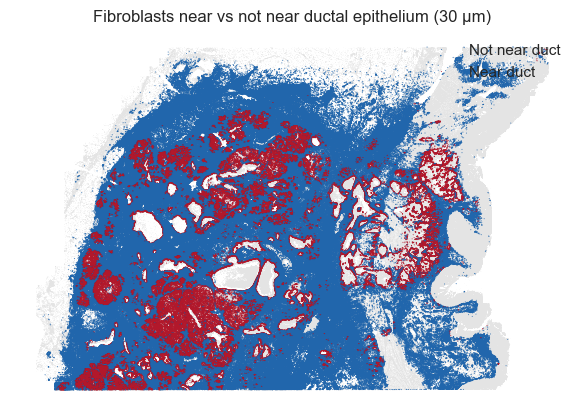

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(
    data=adata.obs,
    x='X_centroid',
    y='Y_centroid',
    color='lightgray',
    s=0.2,
    alpha=0.2,
    linewidth=0,
    ax=ax,
)

sns.scatterplot(
    data=fib_local_df,
    x='X_centroid',
    y='Y_centroid',
    hue='near_status',
    palette={'Near duct': '#b2182b', 'Not near duct': '#2166ac'},
    s=0.6,
    alpha=0.8,
    linewidth=0,
    ax=ax,
)

ax.invert_yaxis()
ax.set_aspect('equal')
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.title(f'Fibroblasts near vs not near ductal epithelium ({radius_um} µm)')
plt.legend(frameon=False, loc='upper right')
plt.tight_layout()
plt.show()

/var/folders/kg/btvhyzjs5fb7f_57bfqf24tr0000gn/T/ipykernel_69223/2264956286.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/var/folders/kg/btvhyzjs5fb7f_57bfqf24tr0000gn/T/ipykernel_69223/2264956286.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/var/folders/kg/btvhyzjs5fb7f_57bfqf24tr0000gn/T/ipykernel_69223/2264956286.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/var/folders/kg/btvhyzjs5fb7f_57bfqf24tr0000gn/T/ipykernel_69223/2264956286.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the 

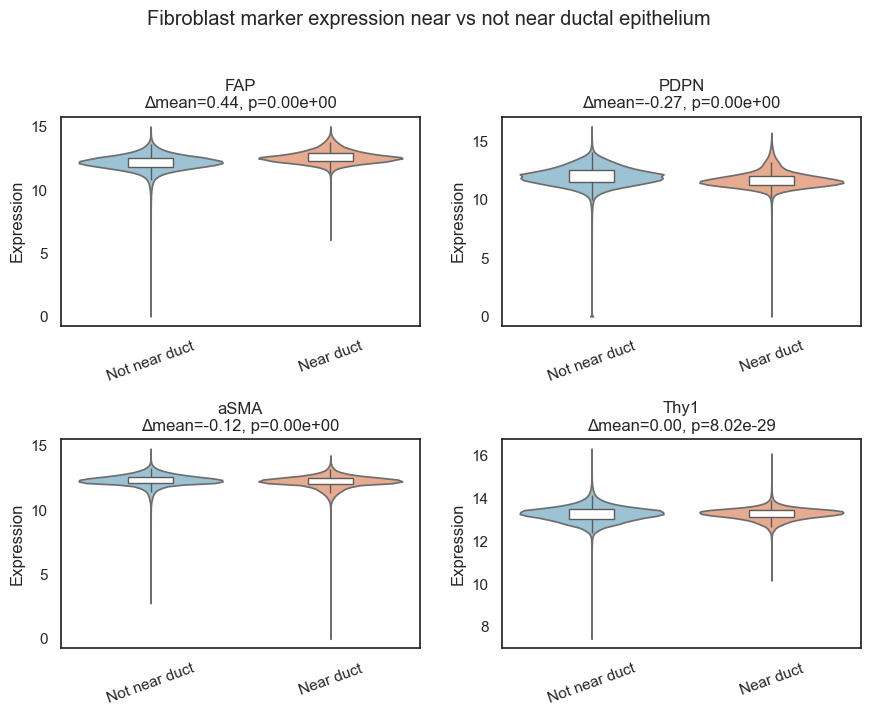

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=False, sharey=False)
axes = axes.ravel()

for ax, marker in zip(axes, markers_present):
    plot_df = marker_long_df[marker_long_df['marker'] == marker].copy()
    sns.violinplot(
        data=plot_df,
        x='near_status',
        y='expr',
        order=['Not near duct', 'Near duct'],
        inner=None,
        cut=0,
        palette={'Near duct': '#f4a582', 'Not near duct': '#92c5de'},
        ax=ax,
    )
    sns.boxplot(
        data=plot_df,
        x='near_status',
        y='expr',
        order=['Not near duct', 'Near duct'],
        width=0.25,
        showcaps=False,
        boxprops={'facecolor': 'white', 'zorder': 3},
        whiskerprops={'linewidth': 1},
        medianprops={'color': 'black'},
        showfliers=False,
        ax=ax,
    )
    stat_row = marker_stats_df[marker_stats_df['marker'] == marker].iloc[0]
    ax.set_title(f"{marker}\nΔmean={stat_row['delta_mean_expr']:.2f}, p={stat_row['p_value']:.2e}")
    ax.set_xlabel('')
    ax.set_ylabel('Expression')
    ax.grid(False)
    ax.tick_params(axis='x', rotation=20)

for ax in axes[len(markers_present):]:
    ax.axis('off')

plt.suptitle('Fibroblast marker expression near vs not near ductal epithelium', y=1.02)
plt.tight_layout()
plt.show()

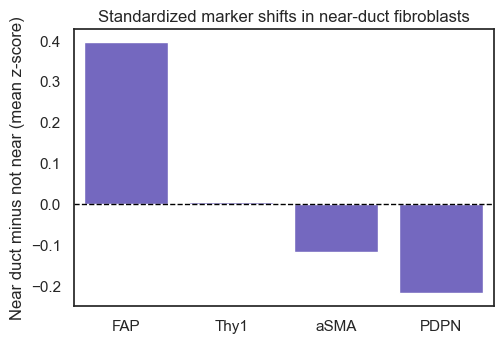

In [13]:
plt.figure(figsize=(5.2, 3.6))
plot_df = marker_stats_df.sort_values('delta_mean_expr_z', ascending=False).copy()
sns.barplot(
    data=plot_df,
    x='marker',
    y='delta_mean_expr_z',
    color='slateblue',
)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.ylabel('Near duct minus not near (mean z-score)')
plt.xlabel('')
plt.title('Standardized marker shifts in near-duct fibroblasts')
plt.grid(False)
plt.tight_layout()
plt.show()

### Interpretation

This analysis uses **Fibroblasts → pancreatic ductal epithelium** local cross-Ripley counts, so the near/not-near label is assigned **per fibroblast**.

That makes it a natural first-pass test of whether fibroblasts directly adjacent to tumour ducts occupy a different marker state from fibroblasts elsewhere in the section.